In [1]:
# Keep the figures from changing between runs.
# Run this before any other cell so that both the seed used for sampling and
# GMM fitting and the timestamp embedded in the saved EPS / PDF stay fixed.
from epot import set_reproducible

set_reproducible()

Generator(PCG64) at 0x7F6CE1A7D9A0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from epot import compute_T_X_to_Z_C, sample_from_gmm

In [3]:
# ---------------------------------------
# 1. GMM A (bottom-left: 2 components)
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])

means_A = np.array(
    [
        [-8.0, -5.0],  # A1 (bottom-left)
        [1.0, -8.0],  # A2 (bottom-left, slightly right)
    ]
)

covs_A = 0.2 * np.array(
    [
        [[1, 0.2], [0.2, 1]],
        [[1, -0.1], [-0.1, 1]],
    ]
)

gmm_A = [2, alpha_A, means_A, covs_A]

# ---------------------------------------
# 2. GMM B (top-right: 2 components + 1 noise component)
# ---------------------------------------
alpha_B = np.array([0.45, 0.45, 0.1])

means_B = np.array(
    [
        [-3.5, 3.5],  # B1 (top-right)
        [3.5, 3.5],  # B2 (top-right, slightly right)
        [9.0, 7.5],  # B3 (noise: further right)
    ]
)

covs_B = 0.2 * np.array(
    [
        [[1, -0.1], [-0.1, 1]],
        [[1, 0.2], [0.2, 1]],
        [[1, 0.0], [0.0, 1]],  # the noise component is isotropic
    ]
)

gmm_B = [3, alpha_B, means_B, covs_B]

/tmp/ipykernel_10915/1732687968.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


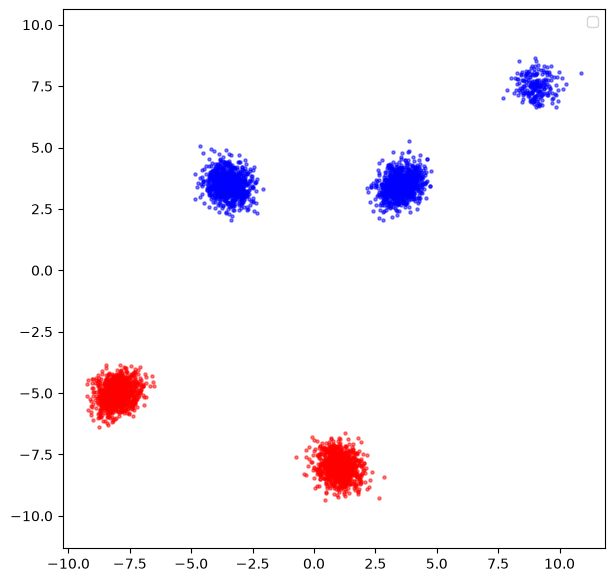

In [4]:
# ---------------------------------------
# Sample from gmm_A
# ---------------------------------------
_, alpha_A, means_A, covs_A = gmm_A
X = sample_from_gmm(alpha_A, means_A, covs_A, N=2000)

# ---------------------------------------
# Sample from gmm_B
# ---------------------------------------
_, alpha_B, means_B, covs_B = gmm_B
Y = sample_from_gmm(alpha_B, means_B, covs_B, N=2000)

plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.5)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.5)
plt.legend()
plt.axis("equal")

plt.show()

[[5.17273491e-03 1.42327459e-01 5.66186119e-07]
 [4.43327265e-01 9.60061216e-04 1.38879439e-11]]
0.5917880863568342


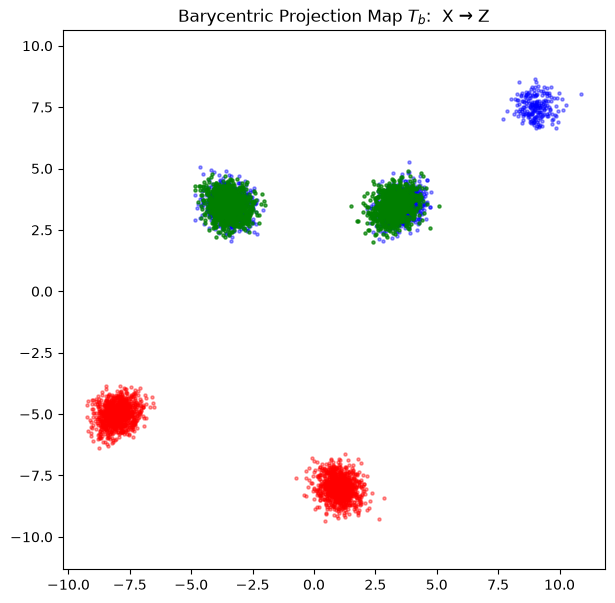

[[ 3.28947947  3.61422254]
 [-3.4902633   4.12615268]
 [ 2.5437606   3.67379828]
 ...
 [-2.62346754  3.25589438]
 [ 2.39090731  2.99147301]
 [ 3.06666693  3.50720523]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


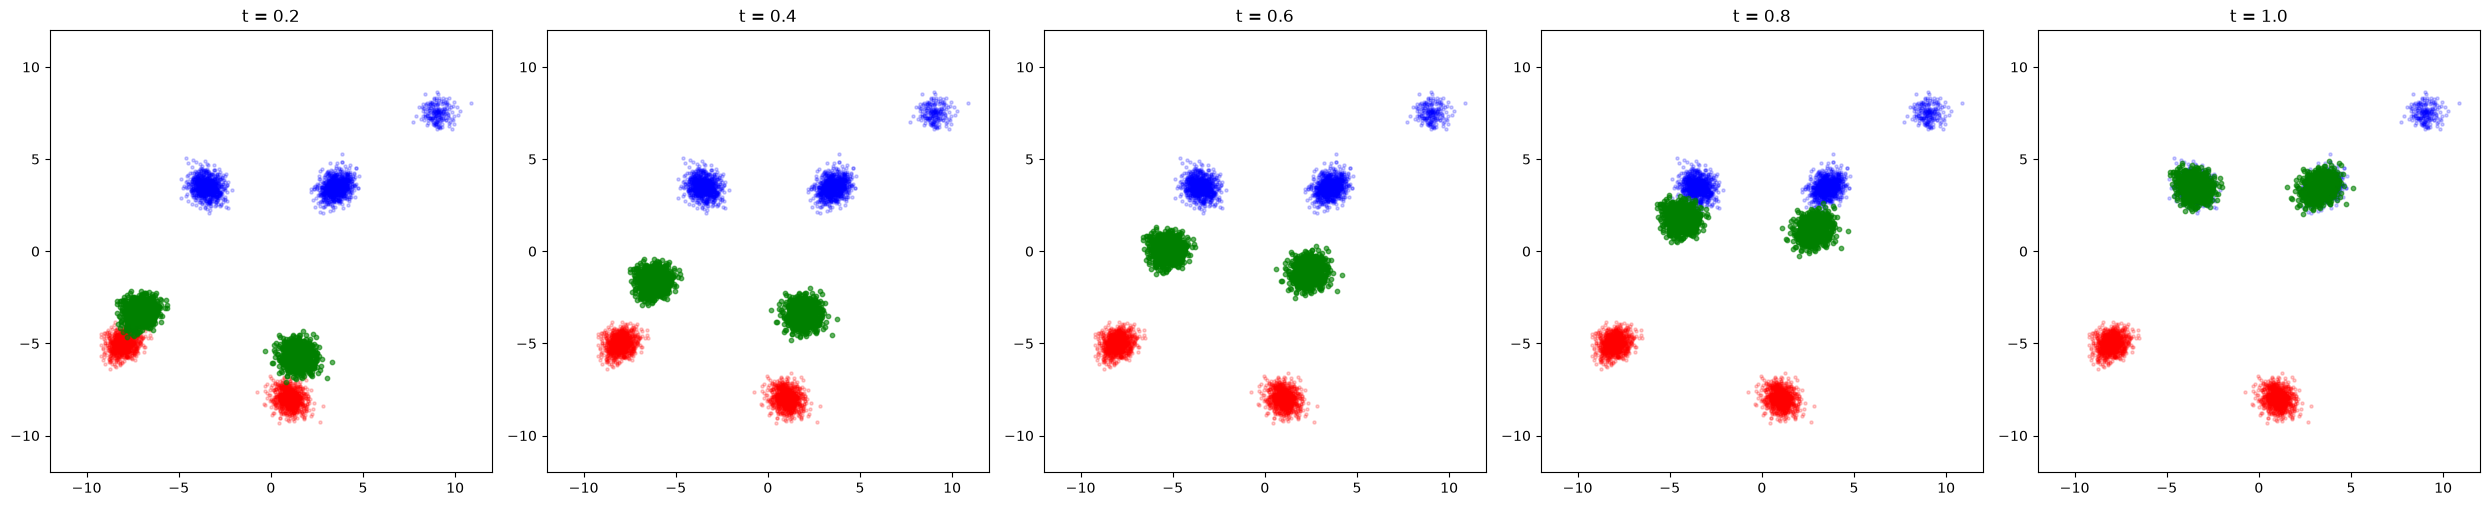

In [5]:
Lambda = 0.25
epsilon = 0.03
# --- Compute Z ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # adjust to match the original GMM fit
    epsilon=epsilon,
    Lambda=Lambda,
    nb_dummies=1,
)


# --- Visualization ---
plt.figure(figsize=(7, 7))

xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]

# Original X (blue)
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# Original Y (red)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# Transported Z (green)
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()

plt.show()
print(Z)


# Parameter settings
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# Layout settings for a single horizontal row
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # Linear interpolation
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # Draw X and Y in the background
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # Draw the current interpolated points Pt
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()

[[2.48504640e-04 3.92304900e-01 1.03446595e-01]
 [4.48251495e-01 5.56951000e-02 5.34045134e-05]]
0.999999999879711


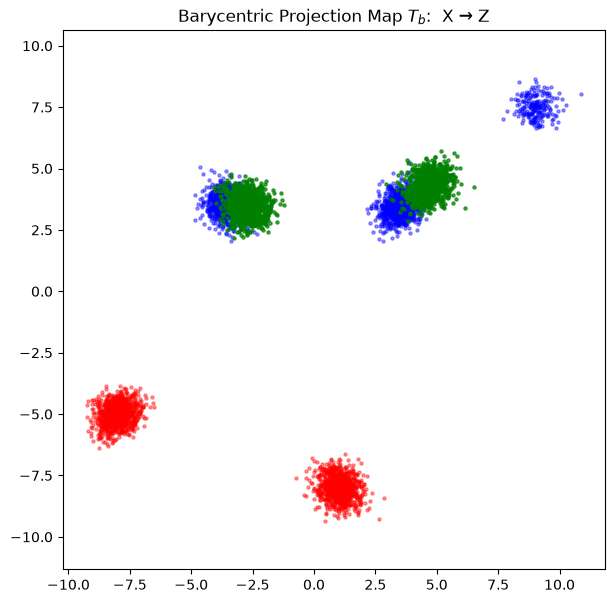

[[ 4.67853818  4.45321526]
 [-2.7139284   4.12537806]
 [ 3.9305276   4.52540293]
 ...
 [-1.86612315  3.27422162]
 [ 3.79161012  3.85270916]
 [ 4.45762978  4.35123259]]


In [6]:
Lambda = 0.5
epsilon = 0.03
# --- Compute Z ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # adjust to match the original GMM fit
    epsilon=epsilon,
    Lambda=2*Lambda,
    nb_dummies=1,
)


# --- Visualization ---
plt.figure(figsize=(7, 7))

# Original X (blue)
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# Original Y (red)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# Transported Z (green)
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()
xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]
plt.show()
print(Z)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


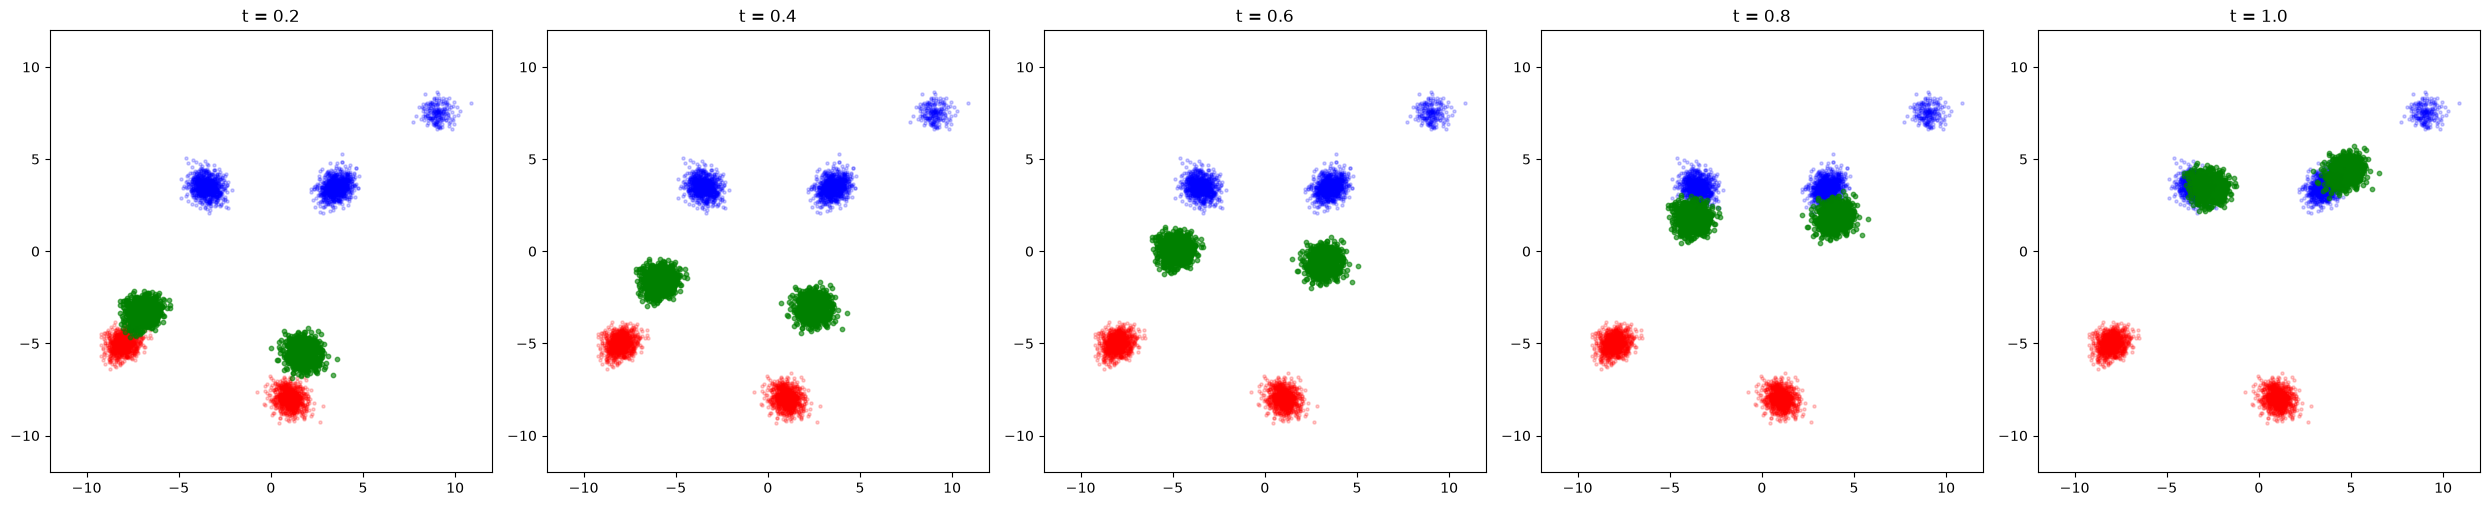

In [7]:
# Parameter settings
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# Layout settings for a single horizontal row
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # Linear interpolation
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # Draw X and Y in the background
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # Draw the current interpolated points Pt
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()